Found 4 .atd files

Parsing VOI-V3A.atd...
Parsing VOI-bilateralMT_group_RFX.atd...
Parsing VOI-inferiorparietal.atd...
Parsing VOI-superiorfrontal.atd...

Parsed 236 rows total
  VOIs:     4
  Subjects: 59
  Groups:   BDD=30, HC=29

Saved long-form CSV: /Volumes/drive/AVP-BDD/derivatives/brainvoyager/SFlow_voi_betas_long.csv

=== Group means ± SDs by VOI ===
                      voi  BDD_lowSF-highC_mean  BDD_lowSF-highC_sd  HC_lowSF-highC_mean  HC_lowSF-highC_sd  BDD_lowSF-lowC_mean  BDD_lowSF-lowC_sd  HC_lowSF-lowC_mean  HC_lowSF-lowC_sd  BDD_lowSF_highC-lowC_mean  BDD_lowSF_highC-lowC_sd  HC_lowSF_highC-lowC_mean  HC_lowSF_highC-lowC_sd
VOI-bilateralMT_group_RFX                0.0334              0.0213               0.0347             0.0200               0.0108             0.0122              0.0203            0.0163                     0.0226                   0.0186                    0.0144                  0.0155
     VOI-inferiorparietal                0.0096              0

/var/folders/hq/ms5zk3kj1pd2kwh1bnvtcr0m0000gn/T/ipykernel_74935/1944740631.py:198: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=sub, x="group", y="lowSF-lowC", order=["BDD", "HC"],


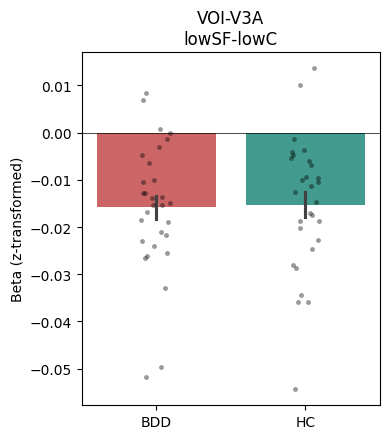

/var/folders/hq/ms5zk3kj1pd2kwh1bnvtcr0m0000gn/T/ipykernel_74935/1944740631.py:214: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=sub, x="group", y="lowSF_highC_minus_lowC", order=["BDD", "HC"],


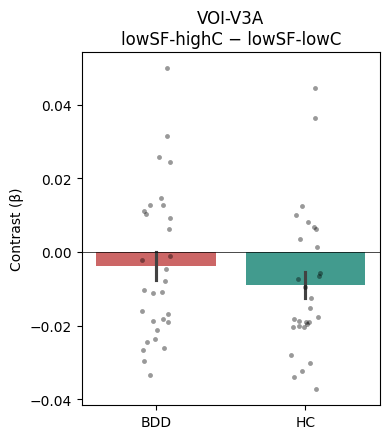

  VOI-V3A: saved VOI-V3A_lowSFlowC.png, VOI-V3A_lowSFcontrastEffect.png


/var/folders/hq/ms5zk3kj1pd2kwh1bnvtcr0m0000gn/T/ipykernel_74935/1944740631.py:198: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=sub, x="group", y="lowSF-lowC", order=["BDD", "HC"],


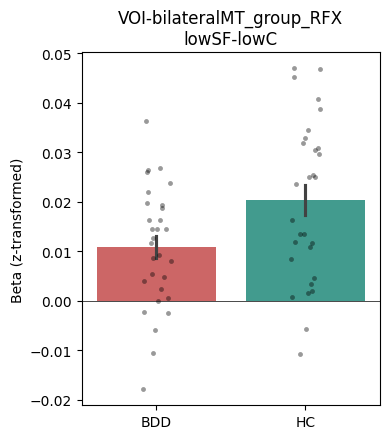

/var/folders/hq/ms5zk3kj1pd2kwh1bnvtcr0m0000gn/T/ipykernel_74935/1944740631.py:214: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=sub, x="group", y="lowSF_highC_minus_lowC", order=["BDD", "HC"],


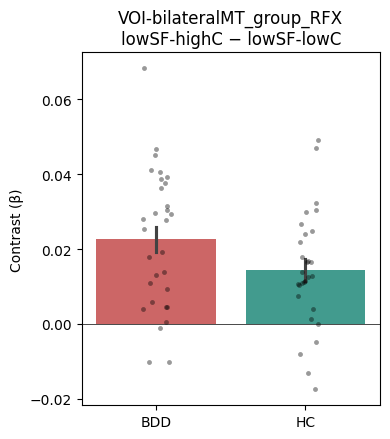

  VOI-bilateralMT_group_RFX: saved VOI-bilateralMT_group_RFX_lowSFlowC.png, VOI-bilateralMT_group_RFX_lowSFcontrastEffect.png


/var/folders/hq/ms5zk3kj1pd2kwh1bnvtcr0m0000gn/T/ipykernel_74935/1944740631.py:198: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=sub, x="group", y="lowSF-lowC", order=["BDD", "HC"],


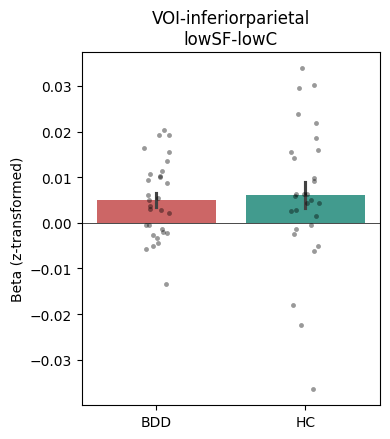

/var/folders/hq/ms5zk3kj1pd2kwh1bnvtcr0m0000gn/T/ipykernel_74935/1944740631.py:214: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=sub, x="group", y="lowSF_highC_minus_lowC", order=["BDD", "HC"],


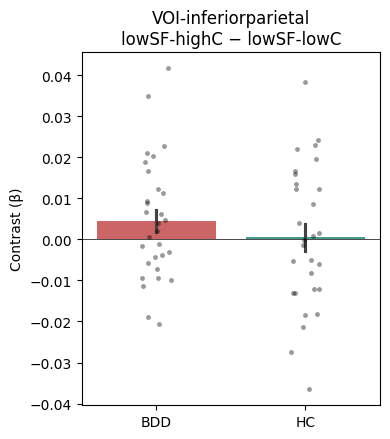

  VOI-inferiorparietal: saved VOI-inferiorparietal_lowSFlowC.png, VOI-inferiorparietal_lowSFcontrastEffect.png


/var/folders/hq/ms5zk3kj1pd2kwh1bnvtcr0m0000gn/T/ipykernel_74935/1944740631.py:198: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=sub, x="group", y="lowSF-lowC", order=["BDD", "HC"],


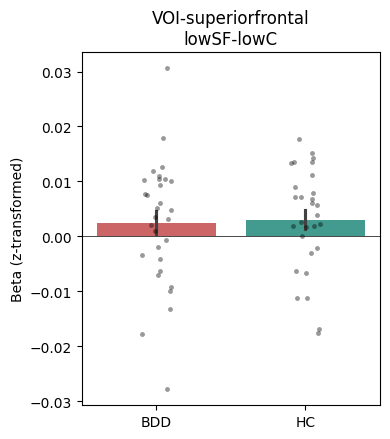

/var/folders/hq/ms5zk3kj1pd2kwh1bnvtcr0m0000gn/T/ipykernel_74935/1944740631.py:214: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=sub, x="group", y="lowSF_highC_minus_lowC", order=["BDD", "HC"],


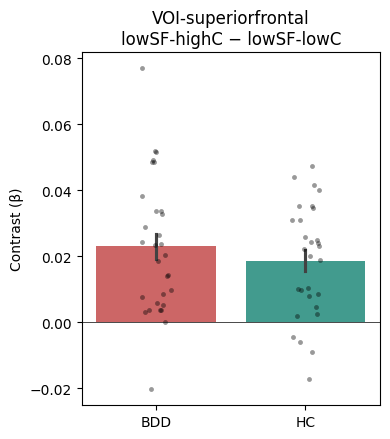

  VOI-superiorfrontal: saved VOI-superiorfrontal_lowSFlowC.png, VOI-superiorfrontal_lowSFcontrastEffect.png

All bar graphs saved to /Volumes/drive/AVP-BDD/derivatives/brainvoyager/voi_bargraphs


In [29]:
import re
import pandas as pd
import numpy as np
from pathlib import Path
from scipy.stats import ttest_ind

# Edit: where the .atd files live (one per VOI/cluster)
ATD_DIR  = Path("/Volumes/drive/AVP-BDD/derivatives/brainvoyager")
ATD_GLOB = "*.atd"      # or "SFlow_*.atd" if you want to limit to specific files
OUT_LONG = ATD_DIR / "SFlow_voi_betas_long.csv"
OUT_WIDE = ATD_DIR / "SFlow_voi_betas_wide.csv"
FIG_DIR  = ATD_DIR / "voi_bargraphs"
FIG_DIR.mkdir(exist_ok=True)

# Match signed floats including scientific notation
NUM_RE = re.compile(r"-?\d+\.?\d*(?:e[+-]?\d+)?")

def parse_atd(path: Path) -> pd.DataFrame:
    """Parse a single .atd file. VOI name is taken from the filename stem."""
    voi_name = path.stem
    text     = path.read_text()
    lines    = text.splitlines()

    # Find the header line with predictor names (the row starting with '"Subjects"')
    predictor_names = None
    for ln in lines:
        if ln.strip().startswith('"Subjects"'):
            predictor_names = re.findall(r'"([^"]+)"', ln)[1:]   # drop "Subjects"
            break
    if not predictor_names:
        raise ValueError(f"No predictor header found in {path.name}")

    rows = []
    for ln in lines:
        m = re.match(r'"Subject\s+(sub-\d+)"(.*)', ln)
        if not m:
            continue
        sub_id  = m.group(1)
        sub_num = int(sub_id.replace("sub-", ""))
        nums    = NUM_RE.findall(m.group(2))
        if len(nums) != len(predictor_names):
            print(f"  WARN {path.name} {sub_id}: found {len(nums)} numbers, "
                  f"expected {len(predictor_names)} — skipping")
            continue
        row = {"voi": voi_name, "subject": sub_num,
               "group": "BDD" if sub_num < 200 else "HC"}
        for name, val in zip(predictor_names, nums):
            row[name] = float(val)
        rows.append(row)

    return pd.DataFrame(rows)


# --- Parse all ATD files ----------------------------------------------------
atd_files = sorted(ATD_DIR.glob(ATD_GLOB))
print(f"Found {len(atd_files)} .atd files\n")

frames = []
for atd in atd_files:
    print(f"Parsing {atd.name}...")
    frames.append(parse_atd(atd))

long_df = pd.concat(frames, ignore_index=True)
print(f"\nParsed {len(long_df)} rows total")
print(f"  VOIs:     {long_df['voi'].nunique()}")
print(f"  Subjects: {long_df['subject'].nunique()}")
print(f"  Groups:   BDD={long_df[long_df.group=='BDD'].subject.nunique()}, "
      f"HC={long_df[long_df.group=='HC'].subject.nunique()}")
long_df.to_csv(OUT_LONG, index=False)
print(f"\nSaved long-form CSV: {OUT_LONG}")


# --- Compute summary contrasts per subject × VOI ----------------------------
condition_cols = ["lowSF-highC", "highSF-highC", "lowSF-lowC", "highSF-lowC"]

long_df["LSF_avg"]       = (long_df["lowSF-highC"]  + long_df["lowSF-lowC"])  / 2
long_df["HSF_avg"]       = (long_df["highSF-highC"] + long_df["highSF-lowC"]) / 2
long_df["highC_avg"]     = (long_df["lowSF-highC"]  + long_df["highSF-highC"]) / 2
long_df["lowC_avg"]      = (long_df["lowSF-lowC"]   + long_df["highSF-lowC"])  / 2
long_df["LSF_minus_HSF"] = long_df["LSF_avg"]   - long_df["HSF_avg"]
long_df["overall_mean"]  = long_df[condition_cols].mean(axis=1)

long_df.to_csv(OUT_WIDE, index=False)


results = []
for voi, sub in long_df.groupby("voi"):
    bdd = sub[sub.group == "BDD"]
    hc  = sub[sub.group == "HC"]

    def test(col):
        t, p = ttest_ind(bdd[col], hc[col], equal_var=False)
        nx, ny = len(bdd), len(hc)
        s_pool = np.sqrt(((nx-1)*bdd[col].std()**2 + (ny-1)*hc[col].std()**2) / (nx+ny-2))
        d = (bdd[col].mean() - hc[col].mean()) / s_pool if s_pool > 0 else np.nan
        return t, p, d

    # Compute the new derived contrast: lowSF-highC minus lowSF-lowC
    # (the contrast effect for the low-SF condition pair across contrast levels)
    sub = sub.copy()
    sub["lowSF_highC_minus_lowC"] = sub["lowSF-highC"] - sub["lowSF-lowC"]
    bdd = sub[sub.group == "BDD"]
    hc  = sub[sub.group == "HC"]

    # Run all tests
    overall_t,     overall_p,     overall_d     = test("overall_mean")
    LSF_t,         LSF_p,         LSF_d         = test("LSF_avg")
    HSF_t,         HSF_p,         HSF_d         = test("HSF_avg")
    SFcontrast_t,  SFcontrast_p,  SFcontrast_d  = test("LSF_minus_HSF")
    lowSFlowC_t,   lowSFlowC_p,   lowSFlowC_d   = test("lowSF-lowC")
    lowSFhighC_t,  lowSFhighC_p,  lowSFhighC_d  = test("lowSF-highC")          # NEW
    lowSFcontr_t,  lowSFcontr_p,  lowSFcontr_d  = test("lowSF_highC_minus_lowC")  # NEW

    results.append({
        "voi": voi, "n_BDD": len(bdd), "n_HC": len(hc),
        # --- Group means and SDs for each condition ----------------------
        "BDD_lowSF-highC_mean":  bdd["lowSF-highC"].mean(),  "BDD_lowSF-highC_sd":  bdd["lowSF-highC"].std(),
        "HC_lowSF-highC_mean":   hc ["lowSF-highC"].mean(),  "HC_lowSF-highC_sd":   hc ["lowSF-highC"].std(),
        "BDD_highSF-highC_mean": bdd["highSF-highC"].mean(), "BDD_highSF-highC_sd": bdd["highSF-highC"].std(),
        "HC_highSF-highC_mean":  hc ["highSF-highC"].mean(), "HC_highSF-highC_sd":  hc ["highSF-highC"].std(),
        "BDD_lowSF-lowC_mean":   bdd["lowSF-lowC"].mean(),   "BDD_lowSF-lowC_sd":   bdd["lowSF-lowC"].std(),
        "HC_lowSF-lowC_mean":    hc ["lowSF-lowC"].mean(),   "HC_lowSF-lowC_sd":    hc ["lowSF-lowC"].std(),
        "BDD_highSF-lowC_mean":  bdd["highSF-lowC"].mean(),  "BDD_highSF-lowC_sd":  bdd["highSF-lowC"].std(),
        "HC_highSF-lowC_mean":   hc ["highSF-lowC"].mean(),  "HC_highSF-lowC_sd":   hc ["highSF-lowC"].std(),
        # --- Derived contrast means/SDs --------------------------------------
        "BDD_LSF_minus_HSF_mean":         bdd["LSF_minus_HSF"].mean(),
        "BDD_LSF_minus_HSF_sd":           bdd["LSF_minus_HSF"].std(),
        "HC_LSF_minus_HSF_mean":          hc ["LSF_minus_HSF"].mean(),
        "HC_LSF_minus_HSF_sd":            hc ["LSF_minus_HSF"].std(),
        "BDD_lowSF_highC-lowC_mean":      bdd["lowSF_highC_minus_lowC"].mean(),
        "BDD_lowSF_highC-lowC_sd":        bdd["lowSF_highC_minus_lowC"].std(),
        "HC_lowSF_highC-lowC_mean":       hc ["lowSF_highC_minus_lowC"].mean(),
        "HC_lowSF_highC-lowC_sd":         hc ["lowSF_highC_minus_lowC"].std(),
        # --- Group comparisons ----------------------------------------------
        "overall_t":     round(overall_t, 3),     "overall_p":     round(overall_p, 4),
        "overall_d":     round(overall_d, 3),
        "LSF_t":         round(LSF_t, 3),         "LSF_p":         round(LSF_p, 4),
        "LSF_d":         round(LSF_d, 3),
        "HSF_t":         round(HSF_t, 3),         "HSF_p":         round(HSF_p, 4),
        "HSF_d":         round(HSF_d, 3),
        "LSFvsHSF_t":    round(SFcontrast_t, 3),  "LSFvsHSF_p":    round(SFcontrast_p, 4),
        "LSFvsHSF_d":    round(SFcontrast_d, 3),
        "lowSFlowC_t":   round(lowSFlowC_t, 3),   "lowSFlowC_p":   round(lowSFlowC_p, 4),
        "lowSFlowC_d":   round(lowSFlowC_d, 3),
        "lowSFhighC_t":  round(lowSFhighC_t, 3),  "lowSFhighC_p":  round(lowSFhighC_p, 4),
        "lowSFhighC_d":  round(lowSFhighC_d, 3),
        "lowSF_highCminuslowC_t": round(lowSFcontr_t, 3),
        "lowSF_highCminuslowC_p": round(lowSFcontr_p, 4),
        "lowSF_highCminuslowC_d": round(lowSFcontr_d, 3),
    })

results_qc = pd.DataFrame(results).sort_values("lowSFlowC_p")

# Bonferroni correction across VOIs for each test type
n_rois = len(results_qc)
p_cols = ["overall_p", "LSF_p", "HSF_p", "LSFvsHSF_p",
          "lowSFlowC_p", "lowSFhighC_p", "lowSF_highCminuslowC_p"]
for col in p_cols:
    results_qc[col + "_bonf"] = (results_qc[col] * n_rois).clip(upper=1.0).round(4)


# --- Pretty-printed compact summaries for inspection ---------------------------
# (1) Group means and SDs for the conditions of interest
print("\n=== Group means ± SDs by VOI ===")
mean_sd_cols = ["voi",
                "BDD_lowSF-highC_mean", "BDD_lowSF-highC_sd",
                "HC_lowSF-highC_mean",  "HC_lowSF-highC_sd",
                "BDD_lowSF-lowC_mean",  "BDD_lowSF-lowC_sd",
                "HC_lowSF-lowC_mean",   "HC_lowSF-lowC_sd",
                "BDD_lowSF_highC-lowC_mean", "BDD_lowSF_highC-lowC_sd",
                "HC_lowSF_highC-lowC_mean",  "HC_lowSF_highC-lowC_sd"]
print(results_qc[mean_sd_cols].round(4).to_string(index=False))

# (2) Group comparison stats sorted by hypothesis-relevant tests
print("\n=== Per-VOI group comparisons (sorted by lowSF-lowC p) ===")
test_cols = ["voi", "n_BDD", "n_HC",
             "lowSFlowC_t",  "lowSFlowC_p",  "lowSFlowC_p_bonf",  "lowSFlowC_d",
             "lowSFhighC_t", "lowSFhighC_p", "lowSFhighC_p_bonf", "lowSFhighC_d",
             "lowSF_highCminuslowC_t", "lowSF_highCminuslowC_p",
             "lowSF_highCminuslowC_p_bonf", "lowSF_highCminuslowC_d"]
print(results_qc[test_cols].to_string(index=False))

# Ensure derived contrast exists on long_df (in case it's not already there)
if "lowSF_highC_minus_lowC" not in long_df.columns:
    long_df["lowSF_highC_minus_lowC"] = long_df["lowSF-highC"] - long_df["lowSF-lowC"]

# =============================================================================
# Bar graphs — two separate figures per VOI:
#   (1) BDD vs HC on lowSF-lowC
#   (2) BDD vs HC on lowSF-highC minus lowSF-lowC
# =============================================================================
PALETTE = {"BDD": "#d55", "HC": "#3a9"}

for voi, sub in long_df.groupby("voi"):

    # --- (1) lowSF-lowC -------------------------------------------------------
    fig, ax = plt.subplots(figsize=(4, 4.5))
    sns.barplot(data=sub, x="group", y="lowSF-lowC", order=["BDD", "HC"],
                palette=PALETTE, errorbar="se", ax=ax)
    sns.stripplot(data=sub, x="group", y="lowSF-lowC", order=["BDD", "HC"],
                  color="black", alpha=0.4, size=3.5, ax=ax)
    ax.axhline(0, color="k", lw=0.5)
    ax.set_title(f"{voi}\nlowSF-lowC")
    ax.set_xlabel("")
    ax.set_ylabel("Beta (z-transformed)")
    plt.tight_layout()
    out1 = FIG_DIR / f"{voi}_lowSFlowC.png"
    plt.savefig(out1, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()

    # --- (2) lowSF-highC minus lowSF-lowC -------------------------------------
    fig, ax = plt.subplots(figsize=(4, 4.5))
    sns.barplot(data=sub, x="group", y="lowSF_highC_minus_lowC", order=["BDD", "HC"],
                palette=PALETTE, errorbar="se", ax=ax)
    sns.stripplot(data=sub, x="group", y="lowSF_highC_minus_lowC", order=["BDD", "HC"],
                  color="black", alpha=0.4, size=3.5, ax=ax)
    ax.axhline(0, color="k", lw=0.5)
    ax.set_title(f"{voi}\nlowSF-highC − lowSF-lowC")
    ax.set_xlabel("")
    ax.set_ylabel("Contrast (β)")
    plt.tight_layout()
    out2 = FIG_DIR / f"{voi}_lowSFcontrastEffect.png"
    plt.savefig(out2, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()

    print(f"  {voi}: saved {out1.name}, {out2.name}")

print(f"\nAll bar graphs saved to {FIG_DIR}")


## correlating w symptom severity / behavioral measures

In [12]:
# extracting contrast sensitivity 

import os
import scipy.io
import numpy as np
import pandas as pd

def extract_estSens_row(mat_path):
    """Extract last row of estCSF array from a .mat file with nested structs."""
    mat_data = scipy.io.loadmat(mat_path, squeeze_me=True, struct_as_record=False)
    
    # Navigate the nested structs
    qcsf_struct = mat_data['qcsf']
    data_struct = qcsf_struct.data
    estSens = data_struct.estSensitivity  # estCSF should be 120x4
    return estSens[-1, :]  # last row

# Base directory (update this to your actual path)
base_dir = '/Volumes/drive/AVP-BDD/behavior'
subject_dirs = [d for d in os.listdir(base_dir) if os.path.isdir(os.path.join(base_dir, d))]

# Store all data in a list of dicts
all_data = []

for subj in subject_dirs:
    subj_path = os.path.join(base_dir, subj, 'qCSF')
    if not os.path.exists(subj_path):
        continue

    # All .mat files for this subject
    mat_files = [f for f in os.listdir(subj_path) if f.endswith('.mat')]
    mat_files_dict = {  # key = session number
        '-1': None,
        '-2': None
    }

    for f in mat_files:
        if '-1_' in f:
            mat_files_dict['-1'] = f
        elif '-2_' in f:
            mat_files_dict['-2'] = f

    # Initialize row with subject ID and NaNs
    row = {
        'subject': subj,
        '0.25-1': np.nan, '0.3928-1': np.nan, '0.6171-1': np.nan, '0.9696-1': np.nan,'1.5233-1': np.nan, '2.3934-1': np.nan, '3.7604-1': np.nan, '5.9080-1': np.nan,'9.2824-1': np.nan, '14.5839-1': np.nan, '22.9133-1': np.nan, '36-1': np.nan,
        '0.25-2': np.nan, '0.3928-2': np.nan, '0.6171-2': np.nan, '0.9696-2': np.nan,'1.5233-2': np.nan, '2.3934-2': np.nan, '3.7604-2': np.nan, '5.9080-2': np.nan,'9.2824-2': np.nan, '14.5839-2': np.nan, '22.9133-2': np.nan, '36-2': np.nan
    }

    for session in ['-1', '-2']:
        mat_file = mat_files_dict[session]
        if mat_file is not None:
            mat_path = os.path.join(subj_path, mat_file)
            try:
                last_row = extract_estSens_row(mat_path)
                row[f'0.25{session}'] = last_row[0]
                row[f'0.3928{session}']      = last_row[1]
                row[f'0.6171{session}']   = last_row[2]
                row[f'0.9696{session}']     = last_row[3]
                row[f'1.5233{session}'] = last_row[4]
                row[f'2.3934{session}']      = last_row[5]
                row[f'3.7604{session}']   = last_row[6]
                row[f'5.9080{session}']     = last_row[7]
                row[f'9.2824{session}'] = last_row[8]
                row[f'14.5839{session}']      = last_row[9]
                row[f'22.9133{session}']   = last_row[10]
                row[f'36{session}']     = last_row[11]
            except Exception as e:
                print(f"Error loading {mat_file} for {subj}: {e}")

    all_data.append(row)

# Convert to DataFrame
df_sens = pd.DataFrame(all_data)



In [23]:
import scipy.io
import numpy as np
import pandas as pd
import statsmodels.api as sm
from pathlib import Path
from scipy.stats import pearsonr, spearmanr
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------------------------------------------------------
# Configuration
# -----------------------------------------------------------------------------
DEMOG_XLSX = Path("/Volumes/drive/AVP-BDD/Cleaned_Demographics.xlsx")
BEHAV_DIR  = Path("/Volumes/drive/AVP-BDD/behavior")
OUT_DIR    = Path("/Volumes/drive/AVP-BDD/derivatives/brainvoyager")

TARGET_VOI       = "VOI-bilateralMT_group_RFX"
BDD_SCORE_COL    = "BABS"        # <-- edit to match your column
SUBJECT_ID_COL   = "sID"                # <-- edit if different
CPD_TARGET_COLS  = ["0.9696-1", "0.9696-2"] # qCSF columns to average → ~1 cpd

CONDITIONS = [
    "lowSF-highC", "highSF-highC", "lowSF-lowC", "highSF-lowC",
    "LSF_avg", "HSF_avg", "LSF_minus_HSF", "lowSF_highCminuslowC",
]

# -----------------------------------------------------------------------------
# Helpers
# -----------------------------------------------------------------------------
def normalize_sub_id(x):
    s = str(x); digits = "".join(c for c in s if c.isdigit())
    return int(digits) if digits else np.nan

def safe_corr(x, y, method="pearson"):
    mask = ~(np.isnan(x) | np.isnan(y))
    if mask.sum() < 4:
        return np.nan, np.nan, mask.sum()
    fn = pearsonr if method == "pearson" else spearmanr
    r, p = fn(x[mask], y[mask])
    return r, p, mask.sum()

# -----------------------------------------------------------------------------
# Load covariates
# -----------------------------------------------------------------------------
demog = pd.read_excel(DEMOG_XLSX)
print(f"Demographics columns: {demog.columns.tolist()}\n")

demog["subject_num"] = demog[SUBJECT_ID_COL].apply(normalize_sub_id)
demog_bdd = demog[["subject_num", BDD_SCORE_COL]].rename(
    columns={"subject_num": "subject", BDD_SCORE_COL: "bdd_severity"}
)

df_sens["subject_num"] = df_sens["subject"].apply(normalize_sub_id)
df_sens["qcsf_1cpd"]   = df_sens[CPD_TARGET_COLS].mean(axis=1, skipna=True)
qcsf_df = df_sens[["subject_num", "qcsf_1cpd"]].rename(columns={"subject_num": "subject"})

# -----------------------------------------------------------------------------
# Filter to bilateral MT and merge covariates
# -----------------------------------------------------------------------------
if TARGET_VOI not in long_df["voi"].unique():
    raise ValueError(f"{TARGET_VOI} not found. Available: "
                     f"{sorted(long_df['voi'].unique())}")

mt = long_df[long_df.voi == TARGET_VOI].copy()
mt["LSF_minus_HSF"]        = mt["LSF_avg"]     - mt["HSF_avg"]
mt["lowSF_highCminuslowC"] = mt["lowSF-highC"] - mt["lowSF-lowC"]

mt = mt.merge(demog_bdd, on="subject", how="left")
mt = mt.merge(qcsf_df,    on="subject", how="left")

print(f"=== {TARGET_VOI} ===")
print(f"Total subjects: {len(mt)}  "
      f"(BDD: {(mt.group=='BDD').sum()}, HC: {(mt.group=='HC').sum()})")
print(f"  with BDD severity:  {mt.bdd_severity.notna().sum()}")
print(f"  with qCSF (1 cpd):  {mt.qcsf_1cpd.notna().sum()}")

# =============================================================================
# PART 1: Correlations
# =============================================================================
# --- BDD severity (within BDD only) -----------------------------------------
mt_bdd = mt[mt.group == "BDD"]
sev_rows = []
for cond in CONDITIONS:
    r_p, p_p, n = safe_corr(mt_bdd[cond].values, mt_bdd["bdd_severity"].values, "pearson")
    r_s, p_s, _ = safe_corr(mt_bdd[cond].values, mt_bdd["bdd_severity"].values, "spearman")
    sev_rows.append({"contrast": cond, "n": n,
                     "pearson_r": round(r_p, 3),  "pearson_p": round(p_p, 4),
                     "spearman_r": round(r_s, 3), "spearman_p": round(p_s, 4)})
sev_df = pd.DataFrame(sev_rows).sort_values("pearson_p")

print(f"\n=== BDD severity correlations in {TARGET_VOI} (BDD only) ===")
print(sev_df.to_string(index=False))
sev_df.to_csv(OUT_DIR / f"{TARGET_VOI}_BDDseverity_correlations.csv", index=False)

# --- qCSF (all subjects + within each group) --------------------------------
qcsf_rows = []
for label, df_sub in [("All subjects", mt), ("BDD only", mt[mt.group=="BDD"]),
                      ("HC only", mt[mt.group=="HC"])]:
    for cond in CONDITIONS:
        r_p, p_p, n = safe_corr(df_sub[cond].values, df_sub["qcsf_1cpd"].values, "pearson")
        r_s, p_s, _ = safe_corr(df_sub[cond].values, df_sub["qcsf_1cpd"].values, "spearman")
        qcsf_rows.append({"analysis": label, "contrast": cond, "n": n,
                          "pearson_r": round(r_p, 3),  "pearson_p": round(p_p, 4),
                          "spearman_r": round(r_s, 3), "spearman_p": round(p_s, 4)})
qcsf_corr_df = pd.DataFrame(qcsf_rows)

print(f"\n=== qCSF (1 cpd) correlations in {TARGET_VOI} ===")
for label in ["All subjects", "BDD only", "HC only"]:
    print(f"\n--- {label} ---")
    print(qcsf_corr_df[qcsf_corr_df.analysis == label]
          .sort_values("pearson_p").to_string(index=False))
qcsf_corr_df.to_csv(OUT_DIR / f"{TARGET_VOI}_qCSF_correlations.csv", index=False)


# =============================================================================
# PART 3: Scatter plots
# =============================================================================
def scatter_corr(df, x_col, y_col, hue_col=None, title=""):
    fig, ax = plt.subplots(figsize=(5, 4))
    if hue_col:
        sns.scatterplot(data=df, x=x_col, y=y_col, hue=hue_col, ax=ax,
                        palette={"BDD": "#d55", "HC": "#3a9"}, s=50, alpha=0.7)
        # Per-group regression lines
        for grp, color in [("BDD", "#d55"), ("HC", "#3a9")]:
            sub = df[df[hue_col] == grp]
            sns.regplot(data=sub, x=x_col, y=y_col, ax=ax, scatter=False, color=color, ci=None)
    else:
        sns.scatterplot(data=df, x=x_col, y=y_col, ax=ax, s=50, alpha=0.7)
        sns.regplot(data=df, x=x_col, y=y_col, ax=ax, scatter=False, color="gray")
    mask = ~(df[x_col].isna() | df[y_col].isna())
    if mask.sum() >= 4:
        r, p = pearsonr(df.loc[mask, x_col], df.loc[mask, y_col])
        ax.set_title(f"{title}\nr = {r:.3f}, p = {p:.3f}, n = {mask.sum()}")
    else:
        ax.set_title(f"{title}\n(insufficient data)")
    plt.tight_layout()
    return fig

for cond in ["lowSF-lowC", "lowSF-highC", "LSF_avg", "lowSF_highCminuslowC"]:
    # BDD severity (within BDD)
    fig = scatter_corr(mt_bdd, "bdd_severity", cond,
                       title=f"{TARGET_VOI}: BDD severity vs {cond}")
    fig.savefig(OUT_DIR / f"corr_{TARGET_VOI}_severity_{cond}.png", dpi=150)
    plt.close()
    # qCSF (all subjects, by group)
    fig = scatter_corr(mt, "qcsf_1cpd", cond, hue_col="group",
                       title=f"{TARGET_VOI}: qCSF (1 cpd) vs {cond}")
    fig.savefig(OUT_DIR / f"corr_{TARGET_VOI}_qcsf_{cond}.png", dpi=150)
    plt.close()

print(f"\nSaved correlation tables, regression summaries, and scatter plots to {OUT_DIR}")

Demographics columns: ['sID', 'age', 'sex', 'sex-label', 'gender', 'gender-label', 'race', 'race-label', 'education', 'edu-label', 'qids_total', 'stai_state', 'stai_trait', 'bdd_ss_symptom', 'bdd_ss_severity', 'group', 'BDDYBOCS', 'BABS']

=== VOI-bilateralMT_group_RFX ===
Total subjects: 59  (BDD: 30, HC: 29)
  with BDD severity:  30
  with qCSF (1 cpd):  59

=== BDD severity correlations in VOI-bilateralMT_group_RFX (BDD only) ===
            contrast  n  pearson_r  pearson_p  spearman_r  spearman_p
       LSF_minus_HSF 30      0.173     0.3603       0.024      0.8990
          lowSF-lowC 30      0.077     0.6867       0.063      0.7401
             HSF_avg 30     -0.076     0.6884       0.011      0.9550
         highSF-lowC 30     -0.074     0.6965      -0.048      0.8013
        highSF-highC 30     -0.067     0.7267       0.022      0.9102
             LSF_avg 30      0.058     0.7607       0.109      0.5667
         lowSF-highC 30      0.036     0.8512      -0.021      0.9111
low

## ROI visualizations

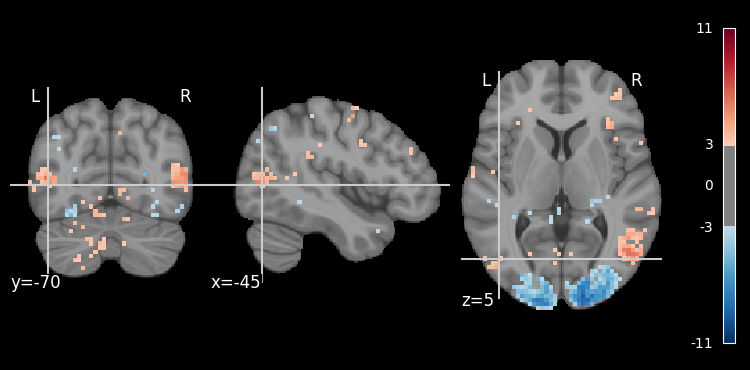

In [32]:
from nilearn import plotting, datasets
import nibabel as nib

mni_template = datasets.load_mni152_template()
plotting.plot_stat_map("/Volumes/drive/AVP-BDD/derivatives/brainvoyager/SFhighvslow_map-1_lowSF-highC +1+ lowSF-lowC +1 ≠ highSF-highC -1+ highSF-lowC -1.nii.gz",
                        bg_img=mni_template, threshold=3.0,
                        display_mode="ortho", cut_coords=(-45, -70, 5))

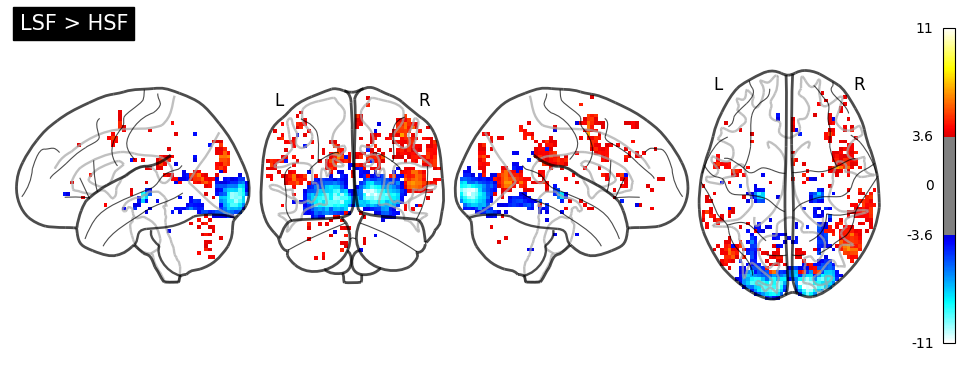

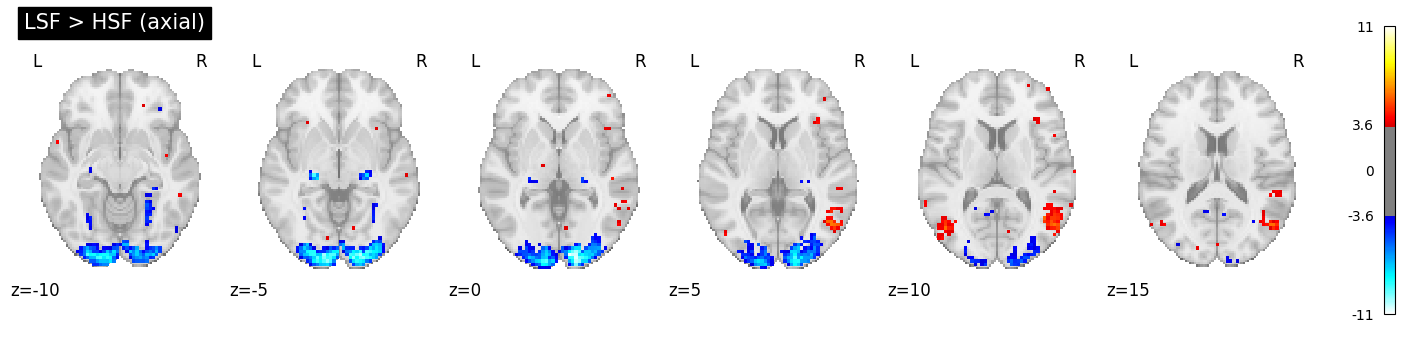

In [33]:
from nilearn import plotting

# Glass brain — transparent whole-brain projection
fig = plotting.plot_glass_brain(
    "/Volumes/drive/AVP-BDD/derivatives/brainvoyager/SFhighvslow_map-1_lowSF-highC +1+ lowSF-lowC +1 ≠ highSF-highC -1+ highSF-lowC -1.nii.gz",
    threshold=3.6, colorbar=True, plot_abs=False,
    cmap="cold_hot", display_mode="lyrz", title="LSF > HSF"
)
fig.savefig("LSF_vs_HSF_glassbrain.png", dpi=300)

# Multi-slice axial
fig = plotting.plot_stat_map(
    "/Volumes/drive/AVP-BDD/derivatives/brainvoyager/SFhighvslow_map-1_lowSF-highC +1+ lowSF-lowC +1 ≠ highSF-highC -1+ highSF-lowC -1.nii.gz",
    threshold=3.6, cmap="cold_hot", display_mode="z",
    cut_coords=[-10, -5, 0, 5, 10, 15], colorbar=True,
    title="LSF > HSF (axial)"
)
fig.savefig("LSF_vs_HSF_axial.png", dpi=300)